# 06 — Optimize the infrasound high-pass filter

This notebook follows:

```text
05_review_157_event_waveforms_reduced_time.ipynb
```

The reduced-time workflow already produced useful event-quality metrics:

- mean-stack SNR;
- median-stack SNR;
- peak mean-stack pressure;
- peak median-stack pressure;
- corrected pick span;
- number of associated channels;
- legacy-event match status.

Those metrics are used here to choose a **representative high-quality test set**
rather than optimizing a filter on a single unusually strong event.

The first experiment varies only the **high-pass corner frequency**. A later
experiment can test whether adding a low-pass corner improves performance beyond
the best high-pass result.

## Experimental goals

1. Select a balanced set of strong, well-associated events.
2. Test raw waveforms and high-pass filters with corners up to 20 Hz.
3. Calculate SNR consistently for every event, channel, and filter.
4. Measure a constrained positive-compression/negative-rarefaction pair.
5. Compare individual channels, mean stacks, and median stacks.
6. Visualize every candidate filter for each selected event.
7. Select a defensible **global high-pass corner**, while retaining the
   event-specific best result as a diagnostic.

06_optimize_infrasound_highpass_filter.ipynb
Valuable experiment, but not a required production notebook.
It tests high-pass choices across a balanced event subset and explicitly warns against event-specific optimization bias. However, the baseline notebook later states that the adopted pressure measurements are unfiltered and that a 1 Hz high-pass may only guide review of weak events.
Therefore, this notebook should not sit in the main numbered production chain unless a high-pass filter is ultimately used for a reported measurement.
Rename it:
S02_evaluate_infrasound_highpass_filters.ipynb
This is excellent supplementary provenance for why a filter was or was not adopted.
Verdict: archive as a supporting experiment.

## 1. Imports and project paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from obspy import Stream, Trace, UTCDateTime, read

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]

REDUCED_REVIEW_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "event_waveform_review_reduced_time"
)

EVENT_FILE = (
    REDUCED_REVIEW_DIR
    / "derived"
    / "reconstructed_reduced_time_events_with_legacy_matches.csv"
)
PICK_ASSIGNMENT_FILE = (
    REDUCED_REVIEW_DIR
    / "derived"
    / "reduced_time_pick_assignments.csv"
)
STACK_METRICS_FILE = REDUCED_REVIEW_DIR / "stack_metrics.csv"
STREAM_FILE = DERIVED_DIR / "bchh_corrected_analysis_window.pkl"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "highpass_filter_optimization"
EVENT_PLOT_DIR = OUTPUT_DIR / "event_filter_panels"
SUMMARY_PLOT_DIR = OUTPUT_DIR / "summary_figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    EVENT_PLOT_DIR,
    SUMMARY_PLOT_DIR,
    DERIVED_OUTPUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Input event metrics: {REDUCED_REVIEW_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Input event metrics: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/event_waveform_review_reduced_time
Output directory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/highpass_filter_optimization


## 2. Configuration

In [2]:
INFRASOUND_CHANNELS = ("HD1", "HD2", "HD3")

BCHH_INFRASOUND_DISTANCES_M = {
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}

REFERENCE_CHANNEL = "HD2"
WIND_CORRECTED_ACOUSTIC_SPEED_MPS = 351.0

# First-stage filter bank: high-pass corner only.
# "raw" is included explicitly as the zero-filter baseline.
HIGH_PASS_CORNERS_HZ = [
    None,
    0.5,
    1.0,
    2.0,
    3.0,
    5.0,
    7.5,
    10.0,
    12.5,
    15.0,
    17.5,
    20.0,
]

FILTER_CORNERS = 4
FILTER_ZEROPHASE = True

# Balanced event selection.
TOP_EVENTS_PER_METRIC = 12
MAX_SELECTED_EVENTS = 30
REQUIRE_THREE_CHANNELS_FOR_PRIMARY_SET = True
MAX_CORRECTED_PICK_SPAN_S = 0.025

# Event extraction relative to reconstructed reduced time.
EXTRACT_PRE_S = 0.20
EXTRACT_POST_S = 0.30

# SNR windows after differential shifting.
NOISE_WINDOW_S = (-0.18, -0.05)
SIGNAL_WINDOW_S = (-0.02, 0.16)

# Constrained compression-rarefaction pair.
PAIR_MINIMUM_LAG_S = 0.004
PAIR_MAXIMUM_LAG_S = 0.16

# A small guard against edge transients from filtering.
FILTER_EDGE_GUARD_S = 0.02

WRITE_EVENT_FILTER_PANELS = True

## 3. Load event metrics, pick assignments, and corrected stream

In [3]:
for required_file in [
    EVENT_FILE,
    PICK_ASSIGNMENT_FILE,
    STACK_METRICS_FILE,
    STREAM_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required input not found: {required_file}"
        )

events = pd.read_csv(EVENT_FILE)
pick_assignments = pd.read_csv(PICK_ASSIGNMENT_FILE)
stack_metrics = pd.read_csv(STACK_METRICS_FILE)
st_corr = read(str(STREAM_FILE), format="PICKLE")

events = events.merge(
    stack_metrics,
    on="reconstructed_event_number",
    how="left",
    validate="one_to_one",
)

events["reduced_event_time"] = pd.to_datetime(
    events["reduced_event_epoch_s"],
    unit="s",
    utc=True,
)

print(st_corr)
print(f"Reconstructed events: {len(events)}")
print(f"Assigned picks: {len(pick_assignments)}")
display(events.head())

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Reconstructed events: 154
Assigned picks: 384


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,...,reduced_event_time,observed_first_pick_time,observed_last_pick_time,legacy_event_number,legacy_match_difference_s,legacy_match_status,mean_stack_snr,median_stack_snr,peak_mean_stack_pa,peak_median_stack_pa
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.003168,3,3,"HD1,HD2,HD3","198,193,194",1.472735e+09,...,2016-09-01 13:07:15.926894903+00:00,2016-09-01 13:07:15.927999973+00:00,2016-09-01 13:07:16.016000032+00:00,1.0,0.045105,matched,14.221739,13.379752,24.417236,24.138475
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.012168,3,3,"HD1,HD2,HD3","201,199,200",1.472735e+09,...,2016-09-01 13:07:16.056894302+00:00,2016-09-01 13:07:16.066999911+00:00,2016-09-01 13:07:16.145999908+00:00,2.0,0.011606,matched,2.493269,2.507255,16.729997,17.136701
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003105,3,3,"HD1,HD2,HD3","204,202,203",1.472735e+09,...,2016-09-01 13:07:16.254831790+00:00,2016-09-01 13:07:16.255000114+00:00,2016-09-01 13:07:16.345999956+00:00,2.0,-0.186332,matched,4.354921,4.044512,26.842182,26.886090
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.030105,2,2,"HD2,HD3","206,205",1.472735e+09,...,2016-09-01 13:07:16.446947098+00:00,2016-09-01 13:07:16.444999933+00:00,2016-09-01 13:07:16.461999893+00:00,NaN,0.359053,unmatched,5.944574,7.437700,11.675367,13.744367
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.001105,2,2,"HD2,HD3","207,208",1.472735e+09,...,2016-09-01 13:07:16.799447298+00:00,2016-09-01 13:07:16.799999952+00:00,2016-09-01 13:07:16.812000036+00:00,3.0,0.006553,matched,2.188643,2.322487,11.533337,11.599114


## 4. Select a balanced high-quality test set

Testing only the largest event would bias the result toward its particular
waveform. Instead, events are selected from several rankings:

- highest median-stack SNR;
- highest mean-stack SNR;
- largest median-stack amplitude;
- largest mean-stack amplitude;
- smallest corrected pick span.

The union of these rankings is then filtered for good association quality.
This produces a test set spanning both strong-amplitude and strong-SNR events.

In [4]:
selection_pool = events.copy()

if REQUIRE_THREE_CHANNELS_FOR_PRIMARY_SET:
    selection_pool = selection_pool.loc[
        selection_pool["channel_count"] == 3
    ].copy()

selection_pool = selection_pool.loc[
    selection_pool["corrected_pick_span_s"]
    <= MAX_CORRECTED_PICK_SPAN_S
].copy()

ranking_columns = [
    ("median_stack_snr", False, "high median-stack SNR"),
    ("mean_stack_snr", False, "high mean-stack SNR"),
    ("peak_median_stack_pa", False, "large median-stack amplitude"),
    ("peak_mean_stack_pa", False, "large mean-stack amplitude"),
    ("corrected_pick_span_s", True, "tight corrected pick cluster"),
]

selected_reasons = {}

for column, ascending, reason in ranking_columns:
    ranked = (
        selection_pool
        .dropna(subset=[column])
        .sort_values(column, ascending=ascending)
        .head(TOP_EVENTS_PER_METRIC)
    )

    for event_number in ranked["reconstructed_event_number"].astype(int):
        selected_reasons.setdefault(event_number, set()).add(reason)

selected_event_numbers = list(selected_reasons)

# Prioritize events selected by multiple independent metrics.
selection_summary = pd.DataFrame([
    {
        "reconstructed_event_number": event_number,
        "selection_reason_count": len(reasons),
        "selection_reasons": "; ".join(sorted(reasons)),
    }
    for event_number, reasons in selected_reasons.items()
])

selection_summary = selection_summary.sort_values(
    ["selection_reason_count", "reconstructed_event_number"],
    ascending=[False, True],
).head(MAX_SELECTED_EVENTS)

selected_events = (
    events
    .merge(
        selection_summary,
        on="reconstructed_event_number",
        how="inner",
    )
    .sort_values("reconstructed_event_number")
    .reset_index(drop=True)
)

print(f"Selected events: {len(selected_events)}")
display(
    selected_events[
        [
            "reconstructed_event_number",
            "channels",
            "corrected_pick_span_s",
            "mean_stack_snr",
            "median_stack_snr",
            "peak_mean_stack_pa",
            "peak_median_stack_pa",
            "selection_reasons",
        ]
    ]
)

selected_events.to_csv(
    DERIVED_OUTPUT_DIR / "selected_filter_test_events.csv",
    index=False,
)

Selected events: 30


,reconstructed_event_number,channels,corrected_pick_span_s,mean_stack_snr,median_stack_snr,peak_mean_stack_pa,peak_median_stack_pa,selection_reasons
0,3,"HD1,HD2,HD3",0.003105,4.354921,4.044512,26.842182,26.886090,tight corrected pick cluster
1,6,"HD1,HD2,HD3",0.002937,4.662234,4.609927,13.359448,13.472581,tight corrected pick cluster
2,9,"HD1,HD2,HD3",0.003168,18.703490,17.663340,88.024868,85.109453,large mean-stack amplitude; large median-stack...
3,13,"HD1,HD2,HD3",0.003168,11.041331,11.055173,696.727431,702.186811,large mean-stack amplitude; large median-stack...
4,14,"HD1,HD2,HD3",0.007168,0.552939,0.567704,641.515251,641.515251,large mean-stack amplitude; large median-stack...
5,15,"HD1,HD2,HD3",0.004168,1.730194,1.828078,133.622069,138.316808,large mean-stack amplitude; large median-stack...
6,18,"HD1,HD2,HD3",0.003168,46.998752,44.225328,124.941535,129.063515,high mean-stack SNR; high median-stack SNR; la...
7,22,"HD1,HD2,HD3",0.004095,21.498853,20.681255,167.816844,168.129158,large mean-stack amplitude; large median-stack...
8,23,"HD1,HD2,HD3",0.005105,20.240477,18.053947,143.442090,145.452256,large mean-stack amplitude; large median-stack...
9,24,"HD1,HD2,HD3",0.003168,23.443684,22.418860,147.419207,151.998749,large mean-stack amplitude; large median-stack...


### Optional amplitude-tier balancing

The selected set can be inspected by amplitude quartile. This prevents the
filter experiment from being dominated only by the largest explosions.

In [5]:
selected_events["amplitude_quartile"] = pd.qcut(
    selected_events["peak_median_stack_pa"].rank(method="first"),
    q=min(4, len(selected_events)),
    labels=False,
    duplicates="drop",
)

display(
    selected_events.groupby("amplitude_quartile").agg(
        event_count=("reconstructed_event_number", "count"),
        minimum_peak_pa=("peak_median_stack_pa", "min"),
        median_peak_pa=("peak_median_stack_pa", "median"),
        maximum_peak_pa=("peak_median_stack_pa", "max"),
        median_snr=("median_stack_snr", "median"),
    )
)

,event_count,minimum_peak_pa,median_peak_pa,maximum_peak_pa,median_snr
amplitude_quartile,,,,,
0,8,13.381839,21.416732,26.886090,16.822046
1,7,27.879210,31.641614,34.767730,34.059729
2,7,40.264360,61.930847,89.616885,50.553224
3,8,112.112923,148.725502,702.186811,19.367601


## 5. Differential time-shifting helpers

In [6]:
def differential_delays_s(
    distances_m: Mapping[str, float],
    *,
    effective_speed_mps: float,
    reference_channel: str,
) -> dict[str, float]:
    reference_distance_m = distances_m[reference_channel]
    return {
        channel: (
            distance_m - reference_distance_m
        ) / effective_speed_mps
        for channel, distance_m in distances_m.items()
    }


DIFFERENTIAL_DELAYS_S = differential_delays_s(
    BCHH_INFRASOUND_DISTANCES_M,
    effective_speed_mps=WIND_CORRECTED_ACOUSTIC_SPEED_MPS,
    reference_channel=REFERENCE_CHANNEL,
)

display(
    pd.DataFrame({
        "channel": list(DIFFERENTIAL_DELAYS_S),
        "differential_delay_s": list(DIFFERENTIAL_DELAYS_S.values()),
    })
)


def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(
    trace: Trace,
    delay_s: float,
) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted

,channel,differential_delay_s
0,HD1,0.091168
1,HD2,0.000000
2,HD3,0.013105


## 6. Filtering, baseline correction, SNR, and paired peaks

In [7]:
def filter_trace(
    trace: Trace,
    highpass_hz: float | None,
) -> Trace:
    out = trace.copy()
    out.detrend("demean")

    if highpass_hz is not None:
        nyquist_hz = 0.5 * float(out.stats.sampling_rate)
        if highpass_hz >= nyquist_hz:
            raise ValueError(
                f"High-pass corner {highpass_hz} Hz is not below Nyquist "
                f"{nyquist_hz} Hz"
            )

        out.filter(
            "highpass",
            freq=highpass_hz,
            corners=FILTER_CORNERS,
            zerophase=FILTER_ZEROPHASE,
        )

    return out


def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - center))
    return 1.4826 * mad


def baseline_correct(
    values: np.ndarray,
    times_s: np.ndarray,
    noise_window_s: tuple[float, float],
) -> tuple[np.ndarray, float]:
    noise_mask = (
        (times_s >= noise_window_s[0])
        & (times_s <= noise_window_s[1])
    )

    if not np.any(noise_mask):
        raise ValueError("Noise window contains no samples")

    baseline = float(np.nanmedian(values[noise_mask]))
    return values - baseline, baseline


def measure_constrained_peak_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    signal_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    signal_indices = np.flatnonzero(
        (times_s >= signal_window_s[0])
        & (times_s <= signal_window_s[1])
    )

    best = None

    for positive_index in signal_indices:
        positive_value = values[positive_index]
        if not np.isfinite(positive_value) or positive_value <= 0:
            continue

        positive_time = times_s[positive_index]

        candidate_negative_indices = signal_indices[
            (times_s[signal_indices] >= positive_time + minimum_lag_s)
            & (times_s[signal_indices] <= positive_time + maximum_lag_s)
        ]

        if len(candidate_negative_indices) == 0:
            continue

        negative_index = candidate_negative_indices[
            np.nanargmin(values[candidate_negative_indices])
        ]
        negative_value = values[negative_index]

        if not np.isfinite(negative_value) or negative_value >= 0:
            continue

        peak_to_peak = positive_value - negative_value

        if best is None or peak_to_peak > best["peak_to_peak_pa"]:
            best = {
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak),
                "positive_time_s": float(positive_time),
                "negative_time_s": float(times_s[negative_index]),
                "positive_negative_lag_s": float(
                    times_s[negative_index] - positive_time
                ),
                "valid_pair": True,
            }

    if best is None:
        return {
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_negative_lag_s": np.nan,
            "valid_pair": False,
        }

    return best


def waveform_metrics(
    values: np.ndarray,
    times_s: np.ndarray,
) -> dict:
    centered, baseline = baseline_correct(
        values,
        times_s,
        NOISE_WINDOW_S,
    )

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    signal_mask = (
        (times_s >= SIGNAL_WINDOW_S[0])
        & (times_s <= SIGNAL_WINDOW_S[1])
    )

    noise_scale = robust_noise_scale(centered[noise_mask])
    absolute_peak = float(
        np.nanmax(np.abs(centered[signal_mask]))
    )
    peak_snr = (
        absolute_peak / noise_scale
        if noise_scale > 0
        else np.nan
    )

    pair = measure_constrained_peak_pair(
        centered,
        times_s,
        signal_window_s=SIGNAL_WINDOW_S,
        minimum_lag_s=PAIR_MINIMUM_LAG_S,
        maximum_lag_s=PAIR_MAXIMUM_LAG_S,
    )

    pair_snr = (
        pair["peak_to_peak_pa"] / noise_scale
        if pair["valid_pair"] and noise_scale > 0
        else np.nan
    )

    return {
        "baseline_pa": baseline,
        "noise_scale_pa": noise_scale,
        "absolute_peak_pa": absolute_peak,
        "peak_snr": peak_snr,
        "pair_snr": pair_snr,
        **pair,
    }

## 7. Extract one event and create shifted channel arrays

In [8]:
def extract_shifted_event_arrays(
    event_epoch_s: float,
    highpass_hz: float | None,
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    start_epoch_s = event_epoch_s - EXTRACT_PRE_S
    end_epoch_s = event_epoch_s + EXTRACT_POST_S

    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = select_one_trace(st_corr, channel).copy()
        trace = shift_trace_to_reference(
            trace,
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(start_epoch_s),
            UTCDateTime(end_epoch_s),
            pad=False,
        )
        trace = filter_trace(trace, highpass_hz)
        shifted_traces[channel] = trace

    sampling_rates = {
        float(trace.stats.sampling_rate)
        for trace in shifted_traces.values()
    }
    if len(sampling_rates) != 1:
        raise ValueError("Infrasound traces have inconsistent sample rates")

    sampling_rate_hz = sampling_rates.pop()

    # Restrict to the common temporal overlap after shifting.
    common_start_s = max(
        float(trace.stats.starttime.timestamp)
        for trace in shifted_traces.values()
    )
    common_end_s = min(
        float(trace.stats.endtime.timestamp)
        for trace in shifted_traces.values()
    )

    sample_count = int(
        np.floor(
            (common_end_s - common_start_s)
            * sampling_rate_hz
        )
    ) + 1

    epoch_grid_s = (
        common_start_s
        + np.arange(sample_count) / sampling_rate_hz
    )
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}

    for channel, trace in shifted_traces.items():
        trace_epoch_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts)
            / sampling_rate_hz
        )

        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_epoch_s,
            trace.data.astype(float),
        )

    return relative_time_s, arrays

## 8. Run the complete high-pass filter bank

In [9]:
metric_rows = []
waveform_cache = {}

for event in selected_events.itertuples(index=False):
    event_number = int(event.reconstructed_event_number)
    event_epoch_s = float(event.reduced_event_epoch_s)

    for highpass_hz in HIGH_PASS_CORNERS_HZ:
        filter_name = (
            "raw"
            if highpass_hz is None
            else f"hp_{highpass_hz:g}_hz"
        )

        times_s, arrays = extract_shifted_event_arrays(
            event_epoch_s,
            highpass_hz,
        )

        channel_centered = {}

        for channel in INFRASOUND_CHANNELS:
            metrics = waveform_metrics(
                arrays[channel],
                times_s,
            )

            centered, _ = baseline_correct(
                arrays[channel],
                times_s,
                NOISE_WINDOW_S,
            )
            channel_centered[channel] = centered

            metric_rows.append({
                "reconstructed_event_number": event_number,
                "filter_name": filter_name,
                "highpass_hz": (
                    np.nan if highpass_hz is None else highpass_hz
                ),
                "waveform_type": channel,
                **metrics,
            })

        matrix = np.vstack([
            channel_centered[channel]
            for channel in INFRASOUND_CHANNELS
        ])
        mean_stack = np.nanmean(matrix, axis=0)
        median_stack = np.nanmedian(matrix, axis=0)

        for waveform_type, values in [
            ("mean_stack", mean_stack),
            ("median_stack", median_stack),
        ]:
            metrics = waveform_metrics(values, times_s)

            metric_rows.append({
                "reconstructed_event_number": event_number,
                "filter_name": filter_name,
                "highpass_hz": (
                    np.nan if highpass_hz is None else highpass_hz
                ),
                "waveform_type": waveform_type,
                **metrics,
            })

        waveform_cache[(event_number, filter_name)] = {
            "times_s": times_s,
            "channels": channel_centered,
            "mean_stack": mean_stack,
            "median_stack": median_stack,
        }

filter_metrics_long = pd.DataFrame(metric_rows)

filter_metrics_long.to_csv(
    DERIVED_OUTPUT_DIR / "filter_bank_metrics_long.csv",
    index=False,
)

print(
    "Metric rows:",
    len(filter_metrics_long),
)
display(filter_metrics_long.head())

Metric rows: 1800


,reconstructed_event_number,filter_name,highpass_hz,waveform_type,baseline_pa,noise_scale_pa,absolute_peak_pa,peak_snr,pair_snr,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_time_s,negative_time_s,positive_negative_lag_s,valid_pair
0,3,raw,NaN,HD1,3.504981e+00,18.899759,28.593325,1.512894,2.978400,28.593325,-27.697720,56.291045,0.026,0.054,0.028,True
1,3,raw,NaN,HD2,-1.112977e+00,17.266893,37.316426,2.161155,2.689124,37.316426,-9.116386,46.432813,0.026,0.058,0.032,True
2,3,raw,NaN,HD3,-3.007682e+00,18.436476,39.879603,2.163082,2.425547,39.879603,-4.838936,44.718539,0.030,0.054,0.024,True
3,3,raw,NaN,mean_stack,1.077248e+00,15.728640,33.900426,2.155331,3.072607,33.900426,-14.427503,48.327929,0.026,0.054,0.028,True
4,3,raw,NaN,median_stack,-2.220446e-16,18.169585,37.316426,2.053785,2.555524,37.316426,-9.116386,46.432813,0.026,0.058,0.032,True


## 9. Filter-level summary across selected events

The primary global comparison uses the **median stack**, because the earlier
reduced-time notebook showed that it was generally less sensitive to one
anomalous channel.

Metrics include:

- median SNR;
- 10th-percentile SNR;
- fraction improved relative to raw;
- fraction degraded by more than 20%;
- median constrained peak-pair lag;
- fraction producing a valid positive-then-negative pair.

In [10]:
stack_metrics = filter_metrics_long.loc[
    filter_metrics_long["waveform_type"] == "median_stack"
].copy()

raw_metrics = (
    stack_metrics.loc[
        stack_metrics["filter_name"] == "raw",
        [
            "reconstructed_event_number",
            "peak_snr",
            "pair_snr",
        ],
    ]
    .rename(columns={
        "peak_snr": "raw_peak_snr",
        "pair_snr": "raw_pair_snr",
    })
)

stack_metrics = stack_metrics.merge(
    raw_metrics,
    on="reconstructed_event_number",
    how="left",
)

stack_metrics["peak_snr_ratio_to_raw"] = (
    stack_metrics["peak_snr"]
    / stack_metrics["raw_peak_snr"]
)
stack_metrics["pair_snr_ratio_to_raw"] = (
    stack_metrics["pair_snr"]
    / stack_metrics["raw_pair_snr"]
)

filter_summary = (
    stack_metrics
    .groupby(
        ["filter_name", "highpass_hz"],
        dropna=False,
    )
    .agg(
        event_count=("reconstructed_event_number", "count"),
        median_peak_snr=("peak_snr", "median"),
        p10_peak_snr=("peak_snr", lambda x: x.quantile(0.10)),
        median_pair_snr=("pair_snr", "median"),
        p10_pair_snr=("pair_snr", lambda x: x.quantile(0.10)),
        fraction_peak_snr_improved=(
            "peak_snr_ratio_to_raw",
            lambda x: np.mean(x > 1.0),
        ),
        fraction_peak_snr_improved_20pct=(
            "peak_snr_ratio_to_raw",
            lambda x: np.mean(x > 1.2),
        ),
        fraction_peak_snr_degraded_20pct=(
            "peak_snr_ratio_to_raw",
            lambda x: np.mean(x < 0.8),
        ),
        valid_pair_fraction=("valid_pair", "mean"),
        median_pair_lag_s=("positive_negative_lag_s", "median"),
    )
    .reset_index()
)

filter_summary["sort_corner_hz"] = (
    filter_summary["highpass_hz"].fillna(-1.0)
)
filter_summary = filter_summary.sort_values("sort_corner_hz")

display(filter_summary)

filter_summary.to_csv(
    DERIVED_OUTPUT_DIR / "filter_bank_summary.csv",
    index=False,
)

,filter_name,highpass_hz,event_count,median_peak_snr,p10_peak_snr,median_pair_snr,p10_pair_snr,fraction_peak_snr_improved,fraction_peak_snr_improved_20pct,fraction_peak_snr_degraded_20pct,valid_pair_fraction,median_pair_lag_s,sort_corner_hz
11,raw,NaN,30,31.585924,5.145602,43.490565,13.946067,0.000000,0.000000,0.000000,0.900000,0.036,-1.0
0,hp_0.5_hz,0.5,30,29.728811,5.147375,44.632139,13.828804,0.366667,0.000000,0.033333,0.900000,0.036,0.5
5,hp_1_hz,1.0,30,30.837285,5.390137,44.065742,11.781320,0.500000,0.000000,0.066667,0.933333,0.040,1.0
7,hp_2_hz,2.0,30,28.285062,6.317883,41.875868,12.660148,0.333333,0.100000,0.266667,0.933333,0.044,2.0
8,hp_3_hz,3.0,30,20.869806,7.209424,28.344808,8.506498,0.300000,0.133333,0.533333,1.000000,0.042,3.0
9,hp_5_hz,5.0,30,18.842167,6.321703,29.389419,11.778608,0.166667,0.100000,0.633333,1.000000,0.034,5.0
10,hp_7.5_hz,7.5,30,20.622554,4.564612,34.568677,6.647144,0.266667,0.033333,0.566667,1.000000,0.030,7.5
1,hp_10_hz,10.0,30,18.510780,3.348430,29.996929,4.086626,0.100000,0.066667,0.733333,1.000000,0.024,10.0
2,hp_12.5_hz,12.5,30,20.443772,2.572452,35.072273,3.311303,0.133333,0.100000,0.600000,1.000000,0.024,12.5
3,hp_15_hz,15.0,30,17.978503,2.552761,32.141538,3.692231,0.100000,0.033333,0.733333,1.000000,0.020,15.0


## 10. Summary figures

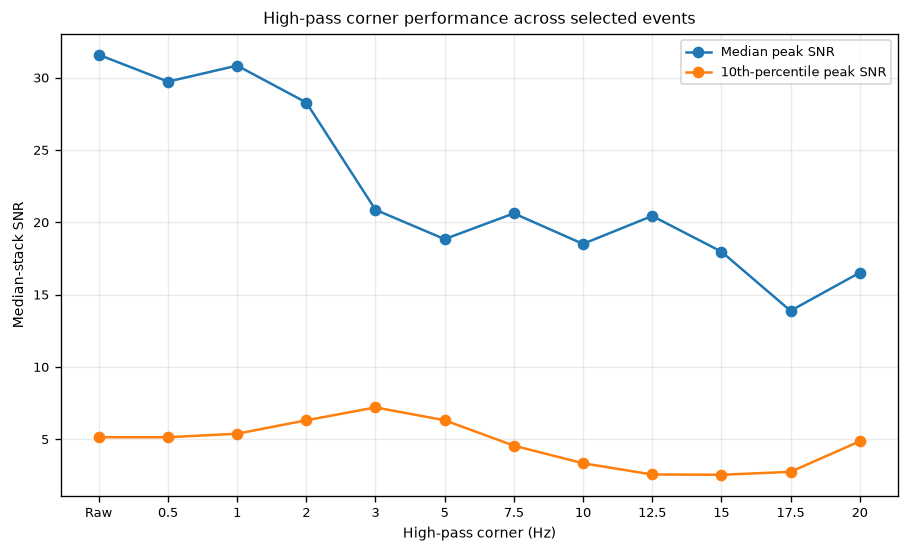

In [11]:
plot_summary = filter_summary.copy()
plot_summary["corner_label"] = plot_summary["highpass_hz"].apply(
    lambda x: "Raw" if pd.isna(x) else f"{x:g}"
)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(
    plot_summary["corner_label"],
    plot_summary["median_peak_snr"],
    marker="o",
    label="Median peak SNR",
)
ax.plot(
    plot_summary["corner_label"],
    plot_summary["p10_peak_snr"],
    marker="o",
    label="10th-percentile peak SNR",
)
ax.set_xlabel("High-pass corner (Hz)")
ax.set_ylabel("Median-stack SNR")
ax.set_title("High-pass corner performance across selected events")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    SUMMARY_PLOT_DIR / "snr_vs_highpass_corner.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

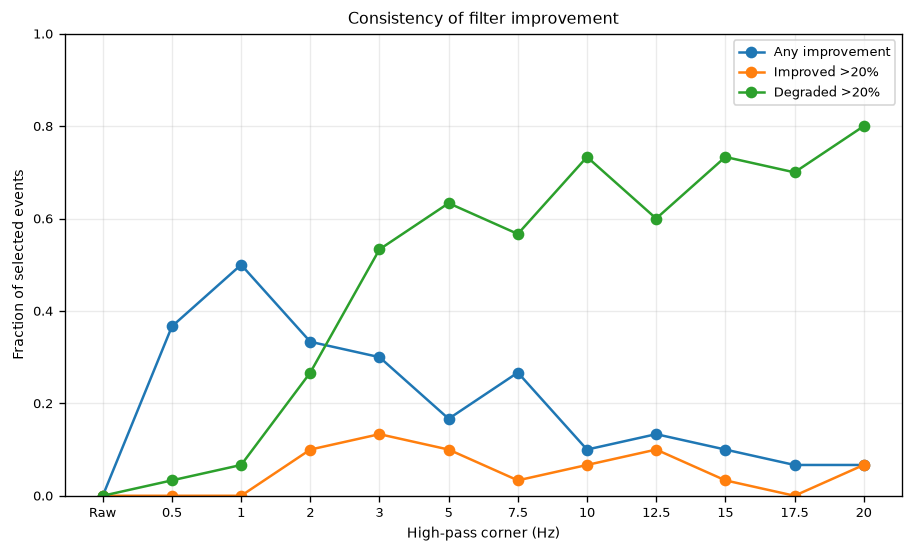

In [12]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(
    plot_summary["corner_label"],
    plot_summary["fraction_peak_snr_improved"],
    marker="o",
    label="Any improvement",
)
ax.plot(
    plot_summary["corner_label"],
    plot_summary["fraction_peak_snr_improved_20pct"],
    marker="o",
    label="Improved >20%",
)
ax.plot(
    plot_summary["corner_label"],
    plot_summary["fraction_peak_snr_degraded_20pct"],
    marker="o",
    label="Degraded >20%",
)
ax.set_xlabel("High-pass corner (Hz)")
ax.set_ylabel("Fraction of selected events")
ax.set_ylim(0, 1)
ax.set_title("Consistency of filter improvement")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    SUMMARY_PLOT_DIR / "improvement_fraction_vs_corner.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 11. Rank the global high-pass choices

A simple composite rank rewards:

- high median peak SNR;
- high 10th-percentile peak SNR;
- frequent improvement;
- infrequent severe degradation;
- a high fraction of valid compression-rarefaction pairs.

The composite is only a decision aid; the component metrics remain visible.

In [13]:
ranked_filters = filter_summary.copy()

ranking_terms = {
    "median_peak_snr": False,
    "p10_peak_snr": False,
    "fraction_peak_snr_improved": False,
    "fraction_peak_snr_degraded_20pct": True,
    "valid_pair_fraction": False,
}

rank_columns = []

for column, ascending in ranking_terms.items():
    rank_column = f"rank_{column}"
    ranked_filters[rank_column] = ranked_filters[column].rank(
        ascending=ascending,
        method="min",
    )
    rank_columns.append(rank_column)

ranked_filters["composite_rank_score"] = (
    ranked_filters[rank_columns].mean(axis=1)
)

ranked_filters = ranked_filters.sort_values(
    [
        "composite_rank_score",
        "fraction_peak_snr_degraded_20pct",
        "sort_corner_hz",
    ]
)

display(
    ranked_filters[
        [
            "filter_name",
            "highpass_hz",
            "median_peak_snr",
            "p10_peak_snr",
            "fraction_peak_snr_improved",
            "fraction_peak_snr_degraded_20pct",
            "valid_pair_fraction",
            "composite_rank_score",
        ]
    ]
)

ranked_filters.to_csv(
    DERIVED_OUTPUT_DIR / "ranked_global_highpass_filters.csv",
    index=False,
)

,filter_name,highpass_hz,median_peak_snr,p10_peak_snr,fraction_peak_snr_improved,fraction_peak_snr_degraded_20pct,valid_pair_fraction,composite_rank_score
8,hp_3_hz,3.0,20.869806,7.209424,0.300000,0.533333,1.000000,3.2
5,hp_1_hz,1.0,30.837285,5.390137,0.500000,0.066667,0.933333,3.8
0,hp_0.5_hz,0.5,29.728811,5.147375,0.366667,0.033333,0.900000,4.6
7,hp_2_hz,2.0,28.285062,6.317883,0.333333,0.266667,0.933333,4.6
9,hp_5_hz,5.0,18.842167,6.321703,0.166667,0.633333,1.000000,5.0
10,hp_7.5_hz,7.5,20.622554,4.564612,0.266667,0.566667,1.000000,5.2
11,raw,NaN,31.585924,5.145602,0.000000,0.000000,0.900000,6.2
2,hp_12.5_hz,12.5,20.443772,2.572452,0.133333,0.600000,1.000000,6.6
1,hp_10_hz,10.0,18.510780,3.348430,0.100000,0.733333,1.000000,7.4
3,hp_15_hz,15.0,17.978503,2.552761,0.100000,0.733333,1.000000,8.2


## 12. Event-specific best filters

These values are retained for diagnostics. They should not automatically replace
the global filter in catalogue-wide comparisons because choosing the maximum
from many filters introduces optimistic selection bias.

In [14]:
event_best_filters = (
    stack_metrics
    .sort_values(
        [
            "reconstructed_event_number",
            "peak_snr",
        ],
        ascending=[True, False],
    )
    .groupby("reconstructed_event_number", as_index=False)
    .first()
)

event_best_filters.to_csv(
    DERIVED_OUTPUT_DIR / "event_specific_best_highpass_filters.csv",
    index=False,
)

display(
    event_best_filters[
        [
            "reconstructed_event_number",
            "filter_name",
            "highpass_hz",
            "peak_snr",
            "pair_snr",
            "positive_peak_pa",
            "negative_peak_pa",
            "peak_to_peak_pa",
            "positive_negative_lag_s",
        ]
    ]
)

,reconstructed_event_number,filter_name,highpass_hz,peak_snr,pair_snr,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_negative_lag_s
0,3,hp_20_hz,20.0,2.478523,4.514588,7.714345,-9.390755,17.105100,0.072
1,6,hp_3_hz,3.0,9.000446,16.106849,22.190064,-17.520415,39.710479,0.068
2,9,hp_3_hz,3.0,9.158134,16.139798,99.892852,-76.152873,176.045724,0.032
3,13,hp_1_hz,1.0,13.201334,0.767663,47.877614,-27.649813,75.527427,0.016
4,14,hp_1_hz,1.0,5.395579,4.177374,389.386838,-31.569459,420.956296,0.056
5,15,raw,0.5,3.254099,1.799332,154.118687,-13.617562,167.736249,0.012
6,18,hp_2_hz,2.0,37.230392,47.483917,184.222830,-50.736324,234.959154,0.024
7,22,hp_12.5_hz,12.5,20.238839,28.956251,126.908835,-54.663044,181.571880,0.024
8,23,hp_12.5_hz,12.5,25.670280,41.869321,114.892398,-72.502004,187.394403,0.024
9,24,hp_20_hz,20.0,56.429881,107.094066,73.248023,-65.763940,139.011963,0.020


## 13. Visualize every filter for every selected event

Each event receives one multi-panel figure showing the baseline-corrected
**median stack** for every high-pass corner. Positive and negative peaks from
the constrained pair are highlighted.

The raw waveform appears first. Filtered panels use identical x-limits, while
each panel scales vertically to its own waveform so weak arrivals remain visible.

In [15]:
def build_event_filter_panel(
    event_number: int,
):
    filter_order = [
        "raw" if corner is None else f"hp_{corner:g}_hz"
        for corner in HIGH_PASS_CORNERS_HZ
    ]

    n_panels = len(filter_order)
    n_columns = 3
    n_rows = int(np.ceil(n_panels / n_columns))

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(12.0, 2.5 * n_rows),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    event_metrics = filter_metrics_long.loc[
        (filter_metrics_long["reconstructed_event_number"] == event_number)
        & (filter_metrics_long["waveform_type"] == "median_stack")
    ].set_index("filter_name")

    for axis, filter_name in zip(axes, filter_order):
        cached = waveform_cache[(event_number, filter_name)]
        times_s = cached["times_s"]
        values = cached["median_stack"]
        row = event_metrics.loc[filter_name]

        axis.plot(times_s, values, linewidth=1.0)
        axis.axhline(0.0, linewidth=0.5, alpha=0.5)
        axis.axvline(0.0, linewidth=0.7, alpha=0.7)
        axis.axvspan(
            SIGNAL_WINDOW_S[0],
            SIGNAL_WINDOW_S[1],
            alpha=0.08,
        )

        if bool(row["valid_pair"]):
            axis.scatter(
                [row["positive_time_s"]],
                [row["positive_peak_pa"]],
                s=34,
                zorder=5,
                label="Positive peak",
            )
            axis.scatter(
                [row["negative_time_s"]],
                [row["negative_peak_pa"]],
                s=34,
                zorder=5,
                label="Negative peak",
            )

        axis.set_title(
            f"{filter_name}\n"
            f"peak SNR={row['peak_snr']:.1f}; "
            f"pair SNR={row['pair_snr']:.1f}; "
            f"lag={row['positive_negative_lag_s']:.3f} s"
        )
        axis.grid(True, axis="x", alpha=0.25)
        axis.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for axis in axes[n_panels:]:
        axis.axis("off")

    for axis in axes[-n_columns:]:
        if axis.has_data():
            axis.set_xlabel("Reduced time relative to event (s)")

    fig.supylabel("Baseline-corrected median-stack pressure (Pa)")

    event_row = selected_events.loc[
        selected_events["reconstructed_event_number"] == event_number
    ].iloc[0]

    fig.suptitle(
        f"Reconstructed event {event_number:03d}: high-pass filter bank\n"
        f"initial stack SNR={event_row['median_stack_snr']:.1f}; "
        f"peak={event_row['peak_median_stack_pa']:.1f} Pa; "
        f"channels={event_row['channels']}",
        fontweight="bold",
    )

    return fig


if WRITE_EVENT_FILTER_PANELS:
    for index, event_number in enumerate(
        selected_events["reconstructed_event_number"].astype(int),
        start=1,
    ):
        fig = build_event_filter_panel(event_number)
        outfile = (
            EVENT_PLOT_DIR
            / f"event_{event_number:03d}_highpass_filter_bank.png"
        )
        fig.savefig(
            outfile,
            dpi=220,
            bbox_inches="tight",
        )
        plt.close(fig)

        if index == 1 or index % 5 == 0 or index == len(selected_events):
            print(
                f"Generated {index} of {len(selected_events)} event panels"
            )

Generated 1 of 30 event panels
Generated 5 of 30 event panels
Generated 10 of 30 event panels
Generated 15 of 30 event panels
Generated 20 of 30 event panels
Generated 25 of 30 event panels
Generated 30 of 30 event panels


## 14. Preview one filter-bank panel

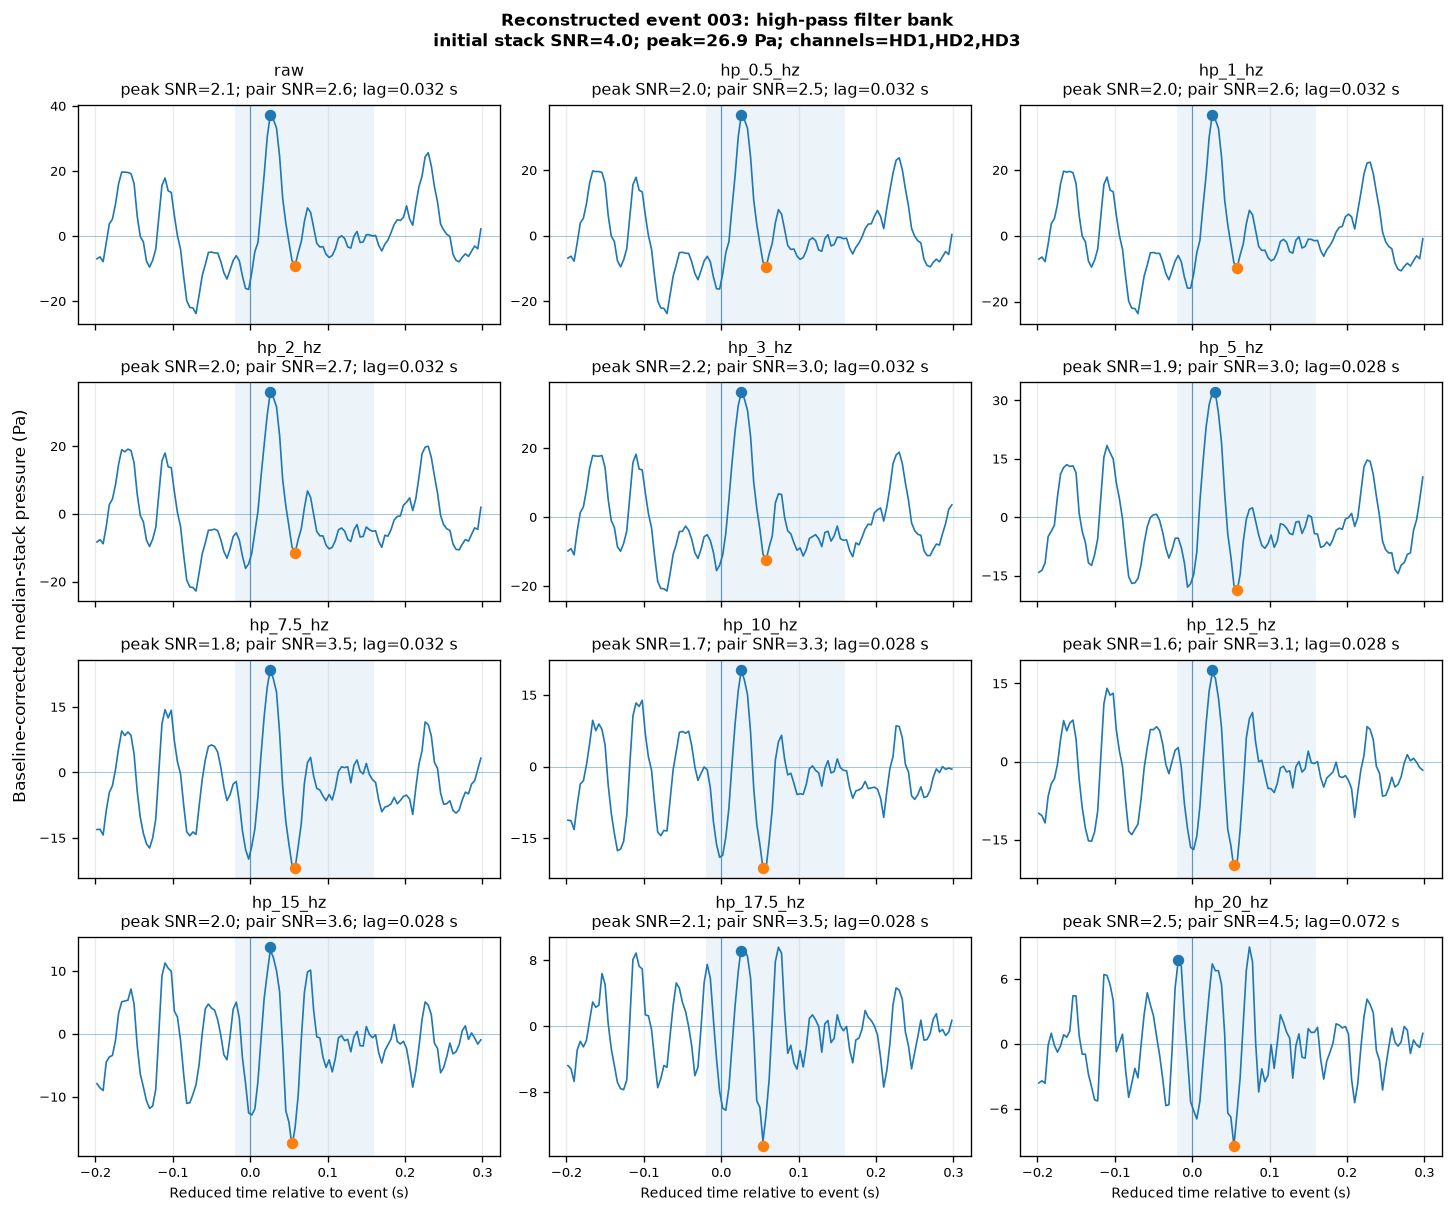

In [16]:
PREVIEW_EVENT_NUMBER = int(
    selected_events.iloc[0]["reconstructed_event_number"]
)

preview_figure = build_event_filter_panel(
    PREVIEW_EVENT_NUMBER
)
plt.show()

## 15. Interpretation and next experiment

Use the global summary to choose a provisional high-pass corner. Preference
should be given to a corner that:

- improves median and low-percentile SNR;
- improves a large fraction of events;
- rarely degrades events severely;
- preserves a plausible positive-then-negative waveform pair.

After selecting the low corner, the next notebook can hold that corner fixed and
test candidate low-pass corners, for example 25, 30, 40, 50, 75, and 100 Hz.